# 01 — Data Exploration

**AI-Based Early Detection and Classification of Foot and Nail Conditions Using Transfer Learning for Rural Healthcare**

This notebook explores the raw dataset before any preprocessing is written. Its
purpose is to answer the questions that *decide* the preprocessing design:

- How many images are there per class, and how imbalanced is it?
- What resolutions, formats and colour modes are present?
- How many images are corrupt, tiny, or duplicated?

Runs both locally and in Google Colab.

## Setup

The cell below detects Colab, mounts Drive and clones the repo if needed, so the
same notebook works in both places.

**Note:** it clones the `claude/foot-nail-disease-ai-fyrdsb` branch explicitly.
The project code is not on `main` yet, so a plain `git clone` would check out an
empty repository.

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# The project code currently lives on this branch, NOT on main. Cloning without
# --branch would check out main, which has no source code in it.
REPO_URL = "https://github.com/gurubasavarajharlapur-jpg/Dissertation_AI_FOOT_NAIL_DISEASE.git"
BRANCH = "claude/foot-nail-disease-ai-fyrdsb"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/Dissertation_AI_FOOT_NAIL_DISEASE")
    if PROJECT_ROOT.exists():
        # Already cloned earlier in this runtime: just pull the latest commits.
        !cd {PROJECT_ROOT} && git checkout {BRANCH} && git pull --ff-only
    else:
        !git clone --branch {BRANCH} {REPO_URL} {PROJECT_ROOT}

    %pip install -q -r {PROJECT_ROOT}/requirements.txt

    # Keep the dataset on Drive, not in the runtime: Colab recycles the VM and
    # you do not want to re-download several hundred MB every session.
    DRIVE_DATA = Path("/content/drive/MyDrive/dissertation_foot_nail/data/raw")
    DRIVE_DATA.mkdir(parents=True, exist_ok=True)

    raw_link = PROJECT_ROOT / "data" / "raw"
    if raw_link.is_symlink():
        print(f"data/raw already linked -> {raw_link.resolve()}")
    else:
        # A fresh clone always leaves a .gitkeep here (it is what keeps the
        # otherwise-empty directory in version control), so "contains .gitkeep
        # and nothing else" counts as empty and is safe to replace with the
        # link. Any real file means the dataset is already on the local disk,
        # and silently discarding it would be much worse than skipping the link.
        leftovers = [p for p in raw_link.iterdir() if p.name != ".gitkeep"]
        if leftovers:
            print(
                f"NOTE: {raw_link} contains {len(leftovers)} file(s) already, so it "
                f"was NOT replaced with a\n      link to Drive. The dataset will be "
                f"lost when this runtime is recycled.\n      Move those files to "
                f"{DRIVE_DATA} and re-run this cell to fix that."
            )
        else:
            for p in raw_link.iterdir():
                p.unlink()
            raw_link.rmdir()
            raw_link.symlink_to(DRIVE_DATA)
            print(f"data/raw -> {DRIVE_DATA}")
else:
    # Local: the notebook lives in notebooks/, so the project root is one level up.
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("Project root    :", PROJECT_ROOT)
print("Running in Colab:", IN_COLAB)

Mounted at /content/drive
Cloning into '/content/Dissertation_AI_FOOT_NAIL_DISEASE'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 57 (delta 14), reused 44 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 45.13 KiB | 641.00 KiB/s, done.
Resolving deltas: 100% (14/14), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.

In [2]:
from src import config

print("Target classes :", config.CLASS_NAMES)
print("Input shape    :", config.INPUT_SHAPE)
print("Random seed    :", config.RANDOM_SEED)
print("Splits         : %.0f/%.0f/%.0f train/val/test"
      % (config.TRAIN_SPLIT * 100, config.VAL_SPLIT * 100, config.TEST_SPLIT * 100))

Target classes : ['healthy', 'nail_fungal', 'foot_wound', 'foot_ulcer']
Input shape    : (224, 224, 3)
Random seed    : 42
Splits         : 70/15/15 train/val/test


## 1. Fetch the datasets

Two public sources:

| Source | Contents | Link |
|---|---|---|
| Mendeley Data `hsj38fwnvr` v3 | Foot imagery (wound / ulcer) | https://data.mendeley.com/datasets/hsj38fwnvr/3 |
| Figshare `5398573` | Onychomycosis — nail fungal infection | https://figshare.com/articles/dataset/5398573 |

`--list` shows what is available without downloading anything. If your network
blocks these hosts, download them manually in a browser and unzip into
`data/raw/`.

In [3]:
!python src/download_data.py --list


=== Mendeley Data hsj38fwnvr (foot) ===

[FAILED] Mendeley Data hsj38fwnvr (foot)
could not reach the Mendeley Data API at https://data.mendeley.com/public-api/datasets/hsj38fwnvr/files?folder_id=root&version=3
  reason: 403 Client Error: Forbidden for url: https://data.mendeley.com/public-api/datasets/hsj38fwnvr/files?folder_id=root&version=3
  If you are behind a proxy, firewall or restricted network, download
  the dataset manually (see --help) and unzip it into data/raw/.

=== Figshare 5398573 (onychomycosis / nail) ===
3 file(s), 2.2 GB total
  - dataset (A1) - thumbnail (1.7GB).zip                        1.7 GB
  - dataset (A2) - thumbnail.zip                              105.0 MB
  - datasets (B1, B2, C, D, E).zip                            358.2 MB

1 of 2 source(s) failed. Use the manual steps in `--help` for those, then run `python src/inspect_data.py`.


In [4]:
# Downloads several hundred MB into data/raw/ (i.e. onto Drive).
# Safe to re-run: files already downloaded are skipped, so an
# interrupted download resumes rather than starting over.
!python src/download_data.py


=== Mendeley Data hsj38fwnvr (foot) ===

[FAILED] Mendeley Data hsj38fwnvr (foot)
could not reach the Mendeley Data API at https://data.mendeley.com/public-api/datasets/hsj38fwnvr/files?folder_id=root&version=3
  reason: 403 Client Error: Forbidden for url: https://data.mendeley.com/public-api/datasets/hsj38fwnvr/files?folder_id=root&version=3
  If you are behind a proxy, firewall or restricted network, download
  the dataset manually (see --help) and unzip it into data/raw/.

=== Figshare 5398573 (onychomycosis / nail) ===
3 file(s), 2.2 GB total
  - dataset (A1) - thumbnail (1.7GB).zip                        1.7 GB
  - dataset (A2) - thumbnail.zip                              105.0 MB
  - datasets (B1, B2, C, D, E).zip                            358.2 MB
  downloaded dataset (A1) - thumbnail (1.7GB).zip (1.7 GB)
  extracted dataset (A1) - thumbnail (1.7GB).zip -> /content/Dissertation_AI_FOOT_NAIL_DISEASE/data/raw/figshare_nail
  downloaded dataset (A2) - thumbnail.zip (105.0 MB)
  

In [5]:
!cd /content/Dissertation_AI_FOOT_NAIL_DISEASE && git pull --ff-only

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.49 KiB | 2.49 MiB/s, done.
From https://github.com/gurubasavarajharlapur-jpg/Dissertation_AI_FOOT_NAIL_DISEASE
   f75f96d..185058e  claude/foot-nail-disease-ai-fyrdsb -> origin/claude/foot-nail-disease-ai-fyrdsb
Updating f75f96d..185058e
Fast-forward
 src/download_data.py | 81 ++++++++++++++++++++++++++++++++++++++++++++++++++--
 1 file changed, 78 insertions(+), 3 deletions(-)


In [6]:
!python src/inspect_data.py --dir data/raw/figshare_nail --no-hash

Inspecting: /content/drive/MyDrive/dissertation_foot_nail/data/raw/figshare_nail
Reading image headers: 100% 1635/1635 [00:14<00:00, 112.04img/s]

Total image files found: 1635

FOLDER STRUCTURE OF /content/drive/MyDrive/dissertation_foot_nail/data/raw/figshare_nail
├── dataset (A1) - thumbnail (1.7GB)/  (259 images)
├── dataset (A2) - thumbnail/  (18 images)
└── datasets (B1, B2, C, D, E)/  (1358 images)
    ├── B1/  (100 images)
    │   ├── naildystrophy/  (50 images)
    │   └── onychomycosis/  (50 images)
    ├── B2/  (194 images)
    │   ├── naildystrophy/  (21 images)
    │   └── onychomycosis/  (173 images)
    ├── C/  (125 images)
    │   ├── naildystrophy/  (68 images)
    │   └── onychomycosis/  (57 images)
    └── D/  (939 images)
        ├── naildystrophy/  (439 images)
        └── onychomycosis/  (500 images)

CLASS DISTRIBUTION (by source folder)
                                     folder  images  percent
 datasets (B1, B2, C, D, E)/D/onychomycosis     500    30.58
 data

In [11]:
import zipfile
from pathlib import Path

DRIVE   = Path('/content/drive/MyDrive/dissertation_foot_nail')
PROJECT = Path('/content/Dissertation_AI_FOOT_NAIL_DISEASE')
RAW     = PROJECT / 'data' / 'raw' / 'mendeley_foot'
MASKS   = PROJECT / 'data' / 'mendeley_masks'

IMAGE_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

# wound_mask.zip holds SEGMENTATION MASKS, not photographs. They are extracted
# outside data/raw/ so the inspector and the training pipeline never pick them
# up — a binary mask counted as a training image is a labelled example of
# nothing. They are kept rather than deleted because they are useful later for
# cropping to the wound region, or for a segmentation extension.
TARGETS = {
    'Normal.zip':     RAW / 'Normal',
    'wound_main.zip': RAW / 'wound_main',
    'wound_mask.zip': MASKS / 'wound_mask',
}


def safe_extract(archive: Path, target: Path) -> int:
    """Extract, refusing entries that would escape the target directory."""
    target.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive) as zf:
        members = []
        for name in zf.namelist():
            p = Path(name)
            if p.is_absolute() or '..' in p.parts:
                raise RuntimeError(f'unsafe entry in {archive.name}: {name}')
            # macOS resource-fork junk: not images, would inflate the counts.
            if name.startswith('__MACOSX/') or Path(name).name.startswith('._'):
                continue
            members.append(name)
        zf.extractall(target, members=members)
    return sum(1 for p in target.rglob('*')
               if p.is_file() and p.suffix.lower() in IMAGE_EXT)


for zip_name, target in TARGETS.items():
    archive = DRIVE / zip_name
    if not archive.exists():
        print(f'MISSING: {archive}')
        continue
    n = safe_extract(archive, target)
    role = 'MASKS — excluded from training' if 'mask' in zip_name else 'training data'
    print(f'{zip_name:<16} -> {n:>5} images   [{role}]')

print('\ndata/raw/mendeley_foot :',
      sum(1 for p in RAW.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXT),
      'images (these go into training)')
print('data/mendeley_masks    :',
      sum(1 for p in MASKS.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXT),
      'images (kept, not trained on)')

print('\nfolder layout:')
for d in sorted(p for p in RAW.rglob('*') if p.is_dir()):
    n = sum(1 for f in d.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXT)
    print(f'  {d.relative_to(RAW)}/  ({n} images)')

Normal.zip       ->  2757 images   [training data]
wound_main.zip   ->  2686 images   [training data]
wound_mask.zip   ->  2686 images   [MASKS — excluded from training]

data/raw/mendeley_foot : 5443 images (these go into training)
data/mendeley_masks    : 2686 images (kept, not trained on)

folder layout:
  Normal/  (0 images)
  Normal/Normal/  (2757 images)
  wound_main/  (0 images)
  wound_main/wound_main/  (2686 images)


In [8]:
import pandas as pd
from pathlib import Path

files = pd.read_csv(config.METRICS_DIR / "raw_data_files.csv")

print("=== FOLDER STRUCTURE (image counts per folder) ===")
counts = files["label"].value_counts().sort_index()
for folder, n in counts.items():
    print(f"{n:>6}  {folder}")

print(f"\n=== {len(files)} images across {len(counts)} folders ===")

print("\n=== SIZE OUTLIERS (montage suspects) ===")
big = files.nlargest(12, "megapixels")[
    ["filename", "label", "width", "height", "megapixels", "file_size_bytes"]
]
print(big.to_string(index=False))

=== FOLDER STRUCTURE (image counts per folder) ===
   259  dataset (A1) - thumbnail (1.7GB)
    18  dataset (A2) - thumbnail
    50  datasets (B1, B2, C, D, E)/B1/naildystrophy
    50  datasets (B1, B2, C, D, E)/B1/onychomycosis
    21  datasets (B1, B2, C, D, E)/B2/naildystrophy
   173  datasets (B1, B2, C, D, E)/B2/onychomycosis
    68  datasets (B1, B2, C, D, E)/C/naildystrophy
    57  datasets (B1, B2, C, D, E)/C/onychomycosis
   439  datasets (B1, B2, C, D, E)/D/naildystrophy
   500  datasets (B1, B2, C, D, E)/D/onychomycosis

=== 1635 images across 10 folders ===

=== SIZE OUTLIERS (montage suspects) ===
                                  filename                            label  width  height  megapixels  file_size_bytes
       L#NAIL#5nail#5nail2007_2#-focus.png dataset (A1) - thumbnail (1.7GB)   2260   13252    29.94952         51950717
         L#NAIL#5nail#5nail2013#-focus.png dataset (A1) - thumbnail (1.7GB)   2260   11588    26.18888         52546236
   L#NAIL#5nail#5nail2

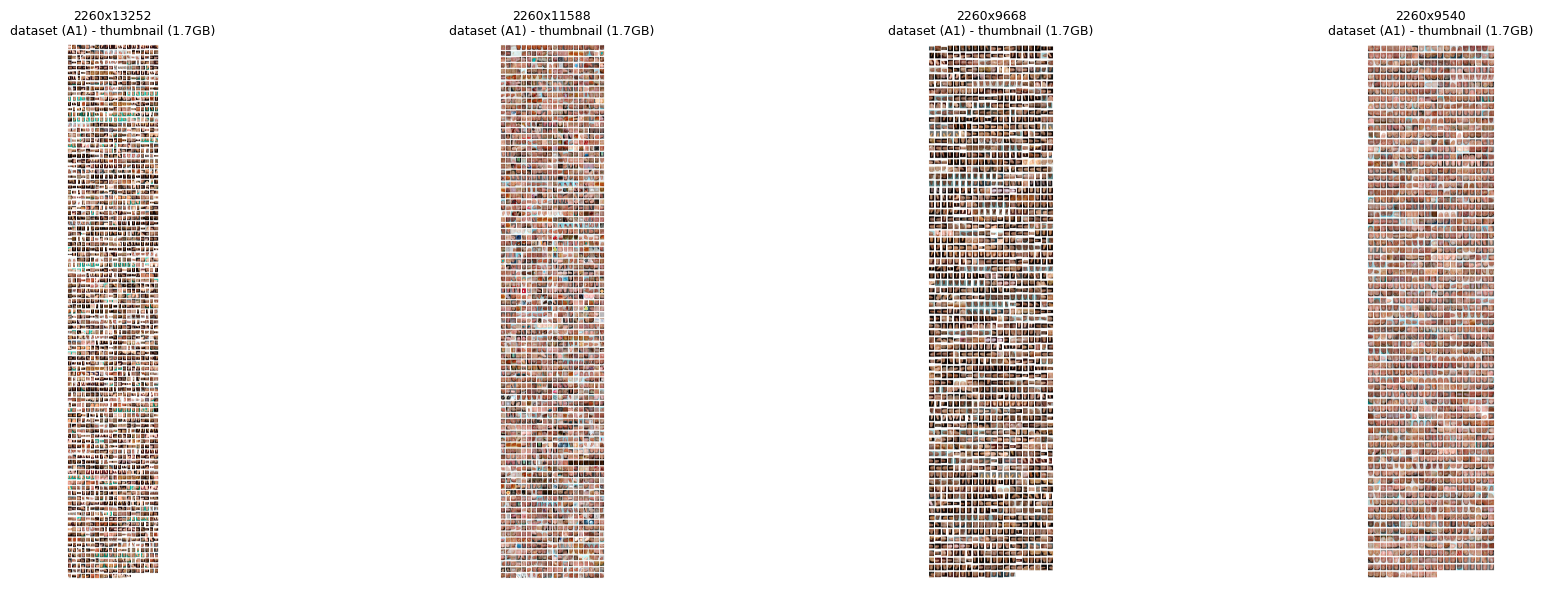

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

suspects = files.nlargest(4, "megapixels")

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, (_, row) in zip(axes, suspects.iterrows()):
    ax.imshow(mpimg.imread(row["path"]))
    ax.set_title(f"{row['width']}x{row['height']}\n{row['label']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
%cd /content/Dissertation_AI_FOOT_NAIL_DISEASE
!rm -rf /tmp/ulcer_repo
!git clone --depth 1 --filter=blob:none --sparse \
    https://github.com/uwm-bigdata/wound-segmentation.git /tmp/ulcer_repo
!cd /tmp/ulcer_repo && git sparse-checkout set --no-cone '/data/**/images/**'

/content
Cloning into '/tmp/ulcer_repo'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 36 (delta 0), reused 26 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 63.68 KiB | 1.72 MiB/s, done.
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 5.21 KiB | 5.21 MiB/s, done.
remote: Enumerating objects: 1330, done.
remote: Counting objects: 100% (1330/1330), done.
remote: Compressing objects: 100% (1330/1330), done.
remote: Total 1330 (delta 0), reused 1330 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1330/1330), 287.53 MiB | 28.21 MiB/s, done.
Updating files: 100% (1376/1376), done.


In [13]:
import shutil
from pathlib import Path

SRC  = Path('/tmp/ulcer_repo/data')
DEST = Path('/content/Dissertation_AI_FOOT_NAIL_DISEASE/data/raw/ulcer_fuseg')
IMAGE_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

# Only images/ folders are copied. The labels/ folders are segmentation masks —
# the same trap as Mendeley's wound_mask.zip — and the sparse pattern above has
# already left them unmaterialised.
copied = 0
for img_dir in sorted(SRC.rglob('images')):
    # e.g. "Foot Ulcer Segmentation Challenge/train" -> fuseg_train
    parts = img_dir.relative_to(SRC).parts
    tag = ('fuseg' if 'Foot Ulcer' in parts[0] else 'medetec') + '_' + parts[-2]
    out = DEST / tag
    out.mkdir(parents=True, exist_ok=True)
    for f in img_dir.iterdir():
        if f.suffix.lower() in IMAGE_EXT:
            shutil.copy2(f, out / f.name)
            copied += 1
    print(f'{tag:<18} {len(list(out.iterdir())):>5} images')

print(f'\n{copied} ulcer images -> {DEST}')
shutil.rmtree('/tmp/ulcer_repo', ignore_errors=True)

fuseg_test           200 images
fuseg_train          810 images
fuseg_validation     200 images
medetec_test           8 images
medetec_train        152 images

1370 ulcer images -> /content/Dissertation_AI_FOOT_NAIL_DISEASE/data/raw/ulcer_fuseg


## 2. Inspect what is in `data/raw/`

This is the key step. Read the output carefully — the folder structure it prints
is what determines how the source folders map onto the four project classes.

In [14]:
!python src/inspect_data.py --dir data/raw/ulcer_fuseg --no-hash

Inspecting: /content/drive/MyDrive/dissertation_foot_nail/data/raw/ulcer_fuseg
Reading image headers: 100% 1370/1370 [00:04<00:00, 306.38img/s]

Total image files found: 1370

FOLDER STRUCTURE OF /content/drive/MyDrive/dissertation_foot_nail/data/raw/ulcer_fuseg
├── fuseg_test/  (200 images)
├── fuseg_train/  (810 images)
├── fuseg_validation/  (200 images)
├── medetec_test/  (8 images)
└── medetec_train/  (152 images)

CLASS DISTRIBUTION (by source folder)
          folder  images  percent
     fuseg_train     810    59.12
      fuseg_test     200    14.60
fuseg_validation     200    14.60
   medetec_train     152    11.09
    medetec_test       8     0.58

Imbalance ratio (largest : smallest) = 101.2 : 1
  -> Notable imbalance. Plan for class weighting (config.USE_CLASS_WEIGHTS) and report macro-averaged F1, not just
     accuracy: a model ignoring the rarest class could still look good.

  barely any test images there, so per-class metrics will be very noisy:
  medetec_test

FILE FO

In [15]:
!cd /content/Dissertation_AI_FOOT_NAIL_DISEASE && git pull --ff-only

remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 15 (delta 7), reused 13 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (15/15), 1.39 MiB | 2.07 MiB/s, done.
From https://github.com/gurubasavarajharlapur-jpg/Dissertation_AI_FOOT_NAIL_DISEASE
   185058e..ed471fd  claude/foot-nail-disease-ai-fyrdsb -> origin/claude/foot-nail-disease-ai-fyrdsb
Updating 185058e..ed471fd
Fast-forward
 .gitignore                               |   3 +
 docs/Proposal_and_Literature_Review.docx | Bin 0 -> 1455345 bytes
 docs/Proposal_and_Literature_Review.txt  | 516 +++++++++++++++++++++++++++++++
 docs/implementation_requirements.md      |  89 ++++++
 src/extract_montages.py                  | 370 ++++++++++++++++++++++
 5 files changed, 978 insertions(+)
 create mode 100644 docs/Proposal_and_Literature_Review.docx
 create mode 100644 docs/Proposal_and_Literature_Review.txt
 create mode 100644 docs/imp

In [16]:
!python src/extract_montages.py --dry-run --preview --limit 5

1635 file(s) under /content/Dissertation_AI_FOOT_NAIL_DISEASE/data/raw/figshare_nail
labels found:
  -focus                  31  -> None
  -etc                    29  -> UNMAPPED
  naildystrophy           28  -> None
  melanonychia            28  -> UNMAPPED
  onychomycosis           27  -> UNMAPPED
  -atypical               21  -> UNMAPPED
  normalnail              21  -> healthy
  whitespot               21  -> UNMAPPED
  nodule                  21  -> UNMAPPED
  onycholysis             20  -> UNMAPPED
  -atypical2               3  -> UNMAPPED
  pincer                   2  -> UNMAPPED
  fluco                    2  -> UNMAPPED
  tinea                    2  -> UNMAPPED
  scio_onychomycosis       2  -> UNMAPPED
  2006 undetermined        1  -> UNMAPPED
  2007 undetermined        1  -> UNMAPPED
  2008 undetermined        1  -> UNMAPPED
  2009 undetermined        1  -> UNMAPPED
  2010 undetermined        1  -> UNMAPPED
  2011 undetermined        1  -> UNMAPPED
  2012 undetermined        1

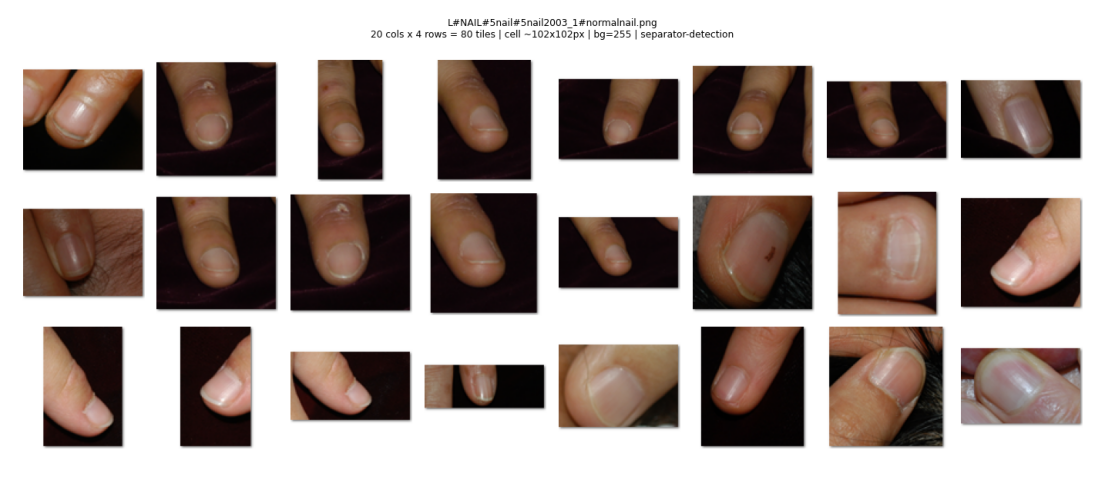

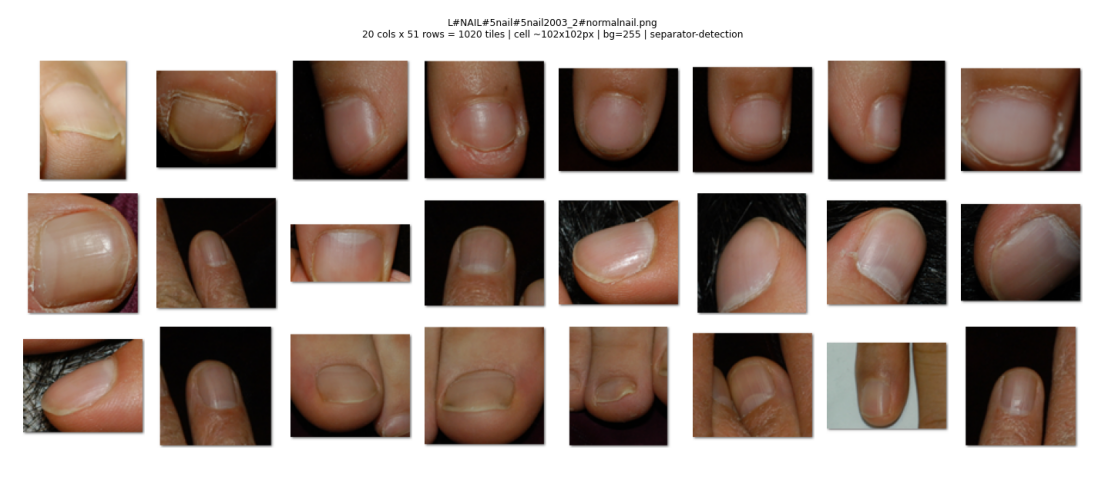

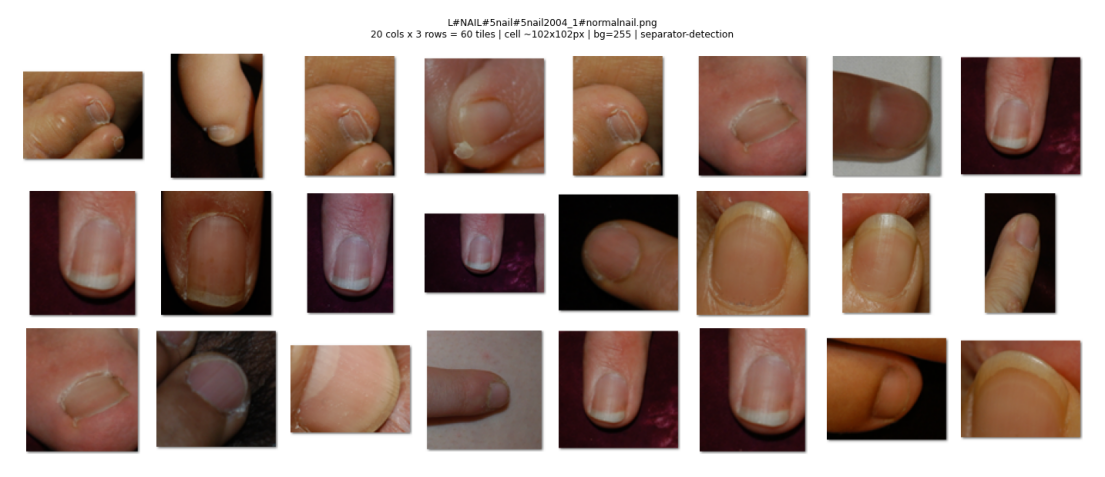

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.image as mpimg

for p in sorted(Path('results/figures/montage_previews').glob('*.png'))[:3]:
    plt.figure(figsize=(14, 8))
    plt.imshow(mpimg.imread(p)); plt.axis('off'); plt.show()

In [18]:
!python src/extract_montages.py --preview
!python src/inspect_data.py --dir data/raw/figshare_nail_tiles --no-hash

1635 file(s) under /content/Dissertation_AI_FOOT_NAIL_DISEASE/data/raw/figshare_nail
labels found:
  -focus                  31  -> None
  -etc                    29  -> UNMAPPED
  naildystrophy           28  -> None
  melanonychia            28  -> UNMAPPED
  onychomycosis           27  -> UNMAPPED
  -atypical               21  -> UNMAPPED
  normalnail              21  -> healthy
  whitespot               21  -> UNMAPPED
  nodule                  21  -> UNMAPPED
  onycholysis             20  -> UNMAPPED
  -atypical2               3  -> UNMAPPED
  pincer                   2  -> UNMAPPED
  fluco                    2  -> UNMAPPED
  tinea                    2  -> UNMAPPED
  scio_onychomycosis       2  -> UNMAPPED
  2006 undetermined        1  -> UNMAPPED
  2007 undetermined        1  -> UNMAPPED
  2008 undetermined        1  -> UNMAPPED
  2009 undetermined        1  -> UNMAPPED
  2010 undetermined        1  -> UNMAPPED
  2011 undetermined        1  -> UNMAPPED
  2012 undetermined        1

In [19]:
!cd /content/Dissertation_AI_FOOT_NAIL_DISEASE && git pull --ff-only
!python src/preprocessing.py --dry-run

remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 12 (delta 9), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 14.27 KiB | 2.04 MiB/s, done.
From https://github.com/gurubasavarajharlapur-jpg/Dissertation_AI_FOOT_NAIL_DISEASE
   ed471fd..6147de3  claude/foot-nail-disease-ai-fyrdsb -> origin/claude/foot-nail-disease-ai-fyrdsb
Updating ed471fd..6147de3
Fast-forward
 docs/implementation_requirements.md |  36 +++
 src/config.py                       |  76 ++++++
 src/preprocessing.py                | 531 ++++++++++++++++++++++++++++++++----
 3 files changed, 592 insertions(+), 51 deletions(-)
seed=42  target size=(224, 224)  classes=['healthy', 'nail_fungal', 'foot_wound', 'foot_ulcer']

[scan data/raw         ] kept  26544
[map to classes        ] kept  25689   dropped   855   6 folder(s) excluded or unmapped
      excluded: figshare_nail/datasets (B1, B2, C, D, E)/D

In [ ]:
!python src/preprocessing.py

seed=42  target size=(224, 224)  classes=['healthy', 'nail_fungal', 'foot_wound', 'foot_ulcer']

[scan data/raw         ] kept  26544
[map to classes        ] kept  25689   dropped   855   6 folder(s) excluded or unmapped
      excluded: figshare_nail/datasets (B1, B2, C, D, E)/D/naildystrophy    439
      excluded: figshare_nail/dataset (A1) - thumbnail (1.7GB)             259
      excluded: figshare_nail/datasets (B1, B2, C, D, E)/C/naildystrophy     68
      excluded: figshare_nail/datasets (B1, B2, C, D, E)/B1/naildystrophy     50
      excluded: figshare_nail/datasets (B1, B2, C, D, E)/B2/naildystrophy     21
      excluded: figshare_nail/dataset (A2) - thumbnail                      18

   per-class after mapping:
      healthy         20853
      foot_wound       2686
      foot_ulcer       1370
      nail_fungal       780

  verifying:  51% 13098/25689 [00:35<00:32, 387.95img/s]